In [17]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

Solving Advection1D by using RK4


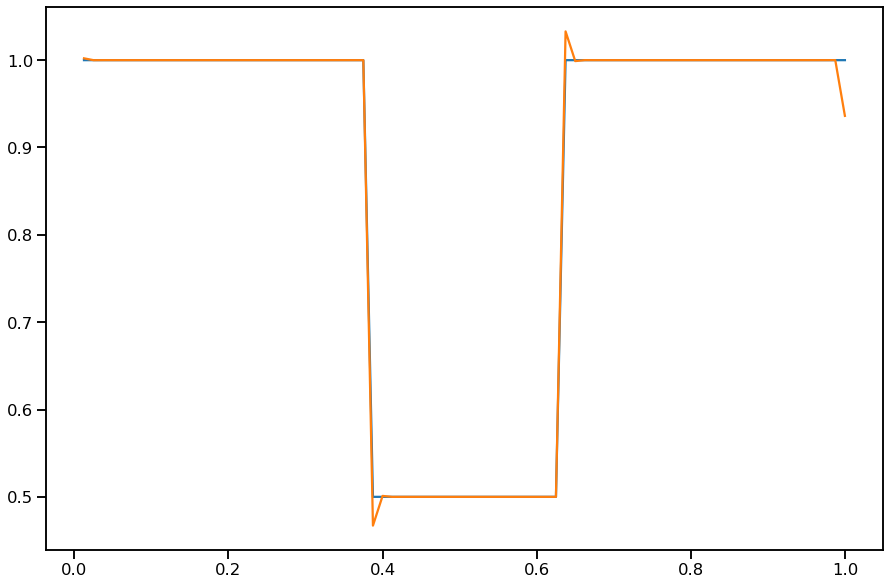

In [18]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':80,'n':1,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('RK4')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()

#u=solver.get_solution()




#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini)
plt.plot(x_coord,y_end)
plt.show()
